In [1]:
#SJL 1/2020
#Script to plot the change in surface length for planets for an example tidal evolution
#plots on a 2D map showing the change in shape and surface

###########################################################
###########################################################
###########################################################
import numpy as np
import scipy as sp
import sys
import os
import struct
from scipy import constants as const

import csv 

#package to use wildcards 
import fnmatch

from scipy.interpolate import LinearNDInterpolator
#from matplotlib.mlab import griddata
from scipy.interpolate import griddata

from scipy import interpolate

#plotting packages
import matplotlib as mpl
#mpl.use('PDF')
import matplotlib.pyplot as plt
import pylab
import matplotlib.cm as cm
from matplotlib import gridspec


cwd = os.getcwd()
print(cwd)
if sys.platform== 'darwin':
    sys.path.insert(0, cwd+'/Support_scipts')
    print(cwd+'/Support_scripts')
elif (sys.platform== 'win32') | (sys.platform== 'win64'):
    sys.path.insert(0,cwd+"\\Support_scipts")


#HERCULES_structures
from HERCULES_structures import *
from surface_size_calc import *
from HERCULES_random_planet_database_structure_1D import *

#functions for calculating non-evenly spaced numerical differentials
from gradients import *

#import colormaps
import colormaps as cmaps
import matplotlib.cm as cm

import svglib.svglib as svglib
svglib.register_font('helvetica', './Helvetica.ttc')

/Users/vq21447/Documents/Lock_2026_SI
/Users/vq21447/Documents/Lock_2026_SI/Support_scripts
CHECK THE LOCATION OF ODYSSEY BACKUP
CHECK THE LOCATION OF ODYSSEY BACKUP


('helvetica', True)

In [2]:
########################################################################################
########################################################################################
########################################################################################
#CONSTANTS
MEarth=5.972E24
LEM=3.5E34
REarth=6.371E6
MMoon=7.34767309E22

aMoon=0.3844E9
aCassini=30*REarth
aRoche=2.9*REarth

#for HERCULES
MEarth_H=5.9879648E24
LEM_H=3.53E34

In [3]:
########################################################################################
########################################################################################
########################################################################################
#PARAMS
Hdir='Earth_correct_params_S3.20c'
Hname='Earth_correct_params_S3.20c'

#flag as to whether to run in plotting mode or whether to redo calculations
flag_calc=0

#number of contor for contour plot
Ncont=100
Nplot=250
AM_plot=np.linspace(0,3.2, Nplot)

#select crust amounts to plot
Ncrust=[1.,3.0,10]
Mfpoints=np.asarray(Ncrust)*2.77E22/MEarth

print('done')

done


In [4]:
########################################################################################
########################################################################################
########################################################################################
#MAIN


if flag_calc==1:
    
    ########################################################################################
    #read in the database
    
    Hdatabase=HERCULES_random_planet_database_1D()
    Hdatabase.make_array(Hdir,Hname)
    Hdatabase.initialize_interpolation([0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],\
                                        [0,0,Mfpoints.tolist(),0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],0], flag_extrap=1)
    
    #extract the latitudes for each Mu point
    Nmu=Hdatabase.parr[0].Nmu
    lat=np.arccos(Hdatabase.parr[0].layers[0].mu)*180/np.pi

    ###########################################
    #values for contour plot
    
    #now run through all AM examples and calculate the gravity
    print('begin')
    
    checkpoints=np.linspace(1,101,101)
    
    gtot=np.zeros((np.size(AM_plot),Nmu))
    
    for i in np.arange(np.size(AM_plot)):
        if (i*1.0/Nplot*100)>checkpoints[0]:
            print(i*1.0/Nplot*100, '%')
            checkpoints=checkpoints[1:]
            
        temp_data=Hdatabase.interp_database(AM_plot[i]*LEM,[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],\
                                           [0,0,[0],0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],0],flag_extrap=1)
    
        temp=np.asarray(temp_data[18])
        gtot[i,:]=np.asarray(temp[:,0])
        
    #calculate the pressure at each of the masses of crust (i.e., depth points)
    AM_grid=np.linspace(AM_plot[0], AM_plot[-1],Ncont*(Ncont+1))


    #MASS FRAC
    #calculate the pressure at each of the points
    pMfrac=np.empty([np.size(AM_grid), np.size(Mfpoints)])
    
    for i in np.arange(np.size(AM_grid)):
    
        temp=Hdatabase.interp_database(AM_grid[i]*LEM,[0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],\
                                       [0,0,Mfpoints.tolist(),0,0,0,0,[0],[0], [0,0], [0,0], 0, 0,[0,0],[0,0],0], \
                                       flag_extrap=1)
        
        pMfrac[i,:]=temp[2]

    temp=np.ones(np.shape(gtot))
    AM=temp*AM_plot[:, None]
    
    lat=temp*(90-np.arccos(Hdatabase.parr[0].mu)*180/np.pi)[None,:]


    
    if 1==0:
        np.savez('Data/Figure3', lat=lat,pMfrac=pMfrac,gtot=gtot,AM_grid=AM_grid)
        
else:
    temp=np.load("Data/Figure3.npz")
    lat=temp['lat']
    pMfrac=temp['pMfrac']
    gtot=temp['gtot']
    AM_grid=temp['AM_grid']

print('done')

done


In [5]:
#calculate the interpolation hulls
lat_grid=np.linspace(0, 90, Ncont*(Ncont+1))
AM_grid=np.linspace(AM_plot[0], AM_plot[-1],Ncont*(Ncont+1))

LLL, TTT = np.meshgrid(AM_grid, lat_grid)

temp=np.ones(np.shape(gtot))
AM=temp*AM_plot[:, None]

# lat=temp*(90-np.arccos(Hdatabase.parr[0].mu)*180/np.pi)[None,:]


GGG=griddata(((AM.flatten(),lat.flatten())),gtot.flatten(),(LLL,TTT))#, method='linear')
 
print('done')

done


/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_13642/4199186963.py:96: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[0][0].annotate("", xytext=(Llim_impacts[0], 4), xy=(Llim_impacts[1], 4), arrowprops=dict(arrowstyle='<->',color='w',lw=1.5,linestyle=":",facecolor="none"))


done


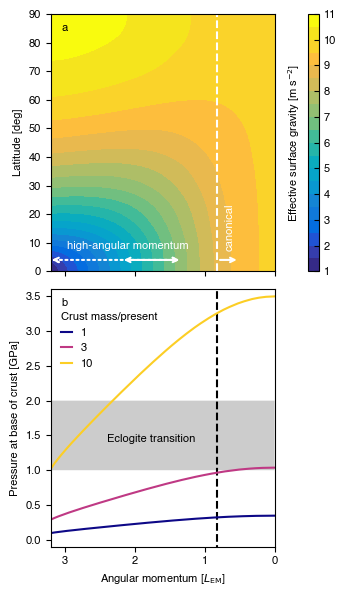

In [6]:


###########################################################################################
###########################################################################################
###########################################################################################

#create a dummy figure figure first to avoid plotting issues
fig = plt.figure(figsize=(3.9,6.5))
font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)
gs = gridspec.GridSpec(2, 1, height_ratios=[0.64,1])
ax=plt.subplot(gs[0])
ax1=plt.subplot(gs[1])
fig.tight_layout()
plt.savefig('Figure3.pdf')
mpl.pyplot.close(fig)


#initialise the figure
fig = plt.figure(figsize=(3.5,6))
gs = gridspec.GridSpec(2, 2,
                      width_ratios=[1,0.05],
                      height_ratios=[1,1])
ax=[[]]
ax[0].append(plt.subplot(gs[0]))
ax[0].append(plt.subplot(gs[2],sharex=ax[0][0]))

ax_col=[[]]
ax_col[0].append(plt.subplot(gs[1]))

font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)

g_contours=np.linspace(1,11,20+1)

g_labels=np.asarray([1,2,3,4,5,6,7,8,9,10,11])


contour1 = ax[0][0].contourf(LLL, TTT, GGG, levels=g_contours, colors=cmaps.parula_r(np.linspace(1, 0, np.size(g_contours)-1)))


#draw lines at Roche limit AM
L_Roche=(LEM)-(MMoon)*np.sqrt(const.G*aRoche*MEarth)
temp=ax[0][0].plot([L_Roche/LEM,L_Roche/LEM], [0,90],'w--',linewidth=1.5)

ax[0][0].set_xlim([3.2, 0.0])


#label axis
cbar1=plt.colorbar(contour1, cax=ax_col[0][0], orientation='vertical',ticks=g_labels)

cbar1.set_label(r'Effective surface gravity [m s$^{-2}$]', labelpad=-36)

for i in np.arange(1):
    ax_col[0][i].tick_params(direction="in")
    
######
#Now plot the lower panel
ax[0][1].fill_between(AM_grid, np.ones(np.size(AM_grid)), 2.0*np.ones(np.size(AM_grid)), alpha=0.2, color='k',edgecolor=None)

ax[0][1].plot([L_Roche/LEM,L_Roche/LEM], [-1,4],'k--',linewidth=1.5)

col=cm.plasma(np.linspace(0,0.9,np.size(Mfpoints)))
for i in np.arange(np.size(Mfpoints)):
    ax[0][1].plot(AM_grid,pMfrac[:,i]/1E9,label=int(Ncrust[i]),color=col[i],linewidth=1.5)
    
# ax[0][0].set_yscale('log')
ax[0][1].set_xlim([3.2, 0.0])
leg=ax[0][1].legend(title="Crust mass/present", frameon=False, loc='upper left',bbox_to_anchor=(0.0,0.95),handlelength=1)
leg._legend_box.align = "left"

ax[0][1].text(0.45, (1.5/3.6), 'Eclogite transition', horizontalalignment='center',verticalalignment='center', fontsize=8,transform=ax[0][1].transAxes, color='k')
        
ax[0][0].set_ylabel("Latitude [deg]")
plt.setp( ax[0][0].get_xticklabels(), visible=False)
ax[0][1].set_ylabel("Pressure at base of crust [GPa]")
ax[0][1].set_xlabel(r"Angular momentum [$L_{\rm EM}$]")

ax[0][0].text(0.05, 0.965, 'a', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][0].transAxes, color='k')
ax[0][1].text(0.05, 0.965, 'b', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][1].transAxes, color='k')

ax[0][1].set_ylim([-0.1,3.6])

#arrows for canonical and high-AM impacts
(xmax,xmin)=ax[0][0].get_xlim()
ax[0][0].annotate("", xytext=(L_Roche/LEM, 4), xy=(L_Roche/LEM-0.1*(xmax-xmin), 4), arrowprops=dict(arrowstyle="->", lw=1.5,color='w'))
ax[0][0].text(1-(L_Roche/LEM-xmin)/(xmax-xmin)+0.035, 0.08, 'canonical', rotation='vertical', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][0].transAxes, color='w')

Llim_impacts=np.asarray([3.4,1.5])-(1-L_Roche/LEM)
Llim_tidal=np.asarray([2.375,1.5])-(1-L_Roche/LEM)
ax[0][0].annotate("",xytext=(Llim_impacts[0], 4),xy=(Llim_impacts[0]-0.12, 4),arrowprops=dict(arrowstyle="<-",color='w',lw=1.5,linestyle="-"))
ax[0][0].annotate("", xytext=(Llim_impacts[0], 4), xy=(Llim_impacts[1], 4), arrowprops=dict(arrowstyle='<->',color='w',lw=1.5,linestyle=":",facecolor="none"))
ax[0][0].annotate("", xytext=(Llim_tidal[0], 4), xy=(Llim_tidal[1], 4), arrowprops=dict(arrowstyle='<->', color='w',lw=1.5,linestyle="-"))
ax[0][0].text(1.055-np.mean(Llim_impacts)/(xmax-xmin), 0.08, 'high-angular momentum', horizontalalignment='center',verticalalignment='bottom', fontsize=8,transform=ax[0][0].transAxes, color='w')


fig.tight_layout()eeeeeeeee
plt.savefig('Figure3.pdf')

print('done')